In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("zomato.csv", encoding="latin-1")
print(df.shape)
df.head()

(391, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
DROP_COLS = ["url", "address", "phone", "reviews_list", "menu_item", "dish_liked"]
df.drop(columns=DROP_COLS, inplace=True)

In [4]:
df.rename(columns={
    "approx_cost(for two people)" : "cost_for_two",
    "listed_in(type)"             : "listing_type",
    "listed_in(city)"             : "listed_city",
    "rest_type"                   : "restaurant_type",
    "book_table"                  : "table_booking",
}, inplace=True)

In [5]:
def parse_rate(val):
    try:
        return float(str(val).split("/")[0].strip())
    except:
        return np.nan

df["rating"] = df["rate"].apply(parse_rate)
df.drop(columns=["rate"], inplace=True)

In [6]:
df["cost_for_two"] = (
    df["cost_for_two"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

In [7]:
for col in ["online_order", "table_booking"]:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [8]:
df.drop_duplicates(inplace=True)
df.dropna(subset=["name"], inplace=True)
print(df.shape)

(390, 11)


In [9]:
df["rating_bucket"] = pd.cut(
    df["rating"],
    bins=[0, 3.0, 3.5, 4.0, 4.5, 5.0],
    labels=["<3.0", "3.0-3.5", "3.5-4.0", "4.0-4.5", "4.5-5.0"]
)
df["is_high_rated"] = (df["rating"] >= 4.0).astype(int)

df.head()

,name,online_order,table_booking,votes,location,restaurant_type,cuisines,cost_for_two,listing_type,listed_city,rating,rating_bucket,is_high_rated
0,Jalsa,1.0,1.0,775.0,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari,4.1,4.0-4.5,1
1,Spice Elephant,1.0,0.0,787.0,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari,4.1,4.0-4.5,1
2,San Churro Cafe,1.0,0.0,918.0,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari,3.8,3.5-4.0,0
3,Addhuri Udupi Bhojana,0.0,0.0,88.0,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari,3.7,3.5-4.0,0
4,Grand Village,0.0,0.0,166.0,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari,3.8,3.5-4.0,0


In [10]:
import sqlite3
conn = sqlite3.connect("zomato_warehouse.db")
df.to_sql("restaurants", conn, if_exists="replace", index=False)
print("✅ Data loaded!")
print("Rows in DB:", pd.read_sql_query("SELECT COUNT(*) as total FROM restaurants", conn).iloc[0,0])

✅ Data loaded!
Rows in DB: 390


In [18]:
q1 = pd.read_sql_query("""
    SELECT location, COUNT(*) AS total_restaurants
    FROM restaurants
    WHERE location IS NOT NULL
    GROUP BY location
    ORDER BY total_restaurants DESC
    LIMIT 10
""", conn)
print(q1)

               location  total_restaurants
0          Banashankari                197
1          Basavanagudi                 73
2             Jayanagar                 59
3    Kumaraswamy Layout                 38
4           Uttarahalli                  7
5           Mysore Road                  7
6           Vijay Nagar                  4
7  Rajarajeshwari Nagar                  2
8              JP Nagar                  2
9       South Bangalore                  1


In [19]:
q2 = pd.read_sql_query("""
    SELECT restaurant_type,
           ROUND(AVG(rating), 2) AS avg_rating,
           COUNT(*) AS count
    FROM restaurants
    WHERE restaurant_type IS NOT NULL
      AND rating IS NOT NULL
    GROUP BY restaurant_type
    HAVING count > 50
    ORDER BY avg_rating DESC
    LIMIT 10
""", conn)
print(q2)

  restaurant_type  avg_rating  count
0   Casual Dining        3.75     75
1     Quick Bites        3.61    152


In [17]:
q3 = pd.read_sql_query("""
    SELECT online_order, table_booking,
           ROUND(AVG(rating), 2) AS avg_rating,
           COUNT(*) AS restaurant_count
    FROM restaurants
    WHERE rating IS NOT NULL
    GROUP BY online_order, table_booking
    ORDER BY avg_rating DESC
""", conn)
print(q3)

   online_order  table_booking  avg_rating  restaurant_count
0           1.0            1.0        4.04                20
1           0.0            1.0        4.00                 1
2           1.0            0.0        3.68               258
3           0.0            0.0        3.56                66


In [20]:
q4 = pd.read_sql_query("""
    SELECT cuisines, COUNT(*) AS count,
           ROUND(AVG(rating), 2) AS avg_rating,
           ROUND(AVG(cost_for_two), 0) AS avg_cost
    FROM restaurants
    WHERE cuisines IS NOT NULL AND rating IS NOT NULL
    GROUP BY cuisines
    ORDER BY count DESC
    LIMIT 5
""", conn)
print(q4)

                              cuisines  count  avg_rating  avg_cost
0                         South Indian     28        3.74     200.0
1                North Indian, Chinese     17        3.59     541.0
2                         North Indian     12        3.33     438.0
3                            Fast Food      9        3.37     244.0
4  South Indian, North Indian, Chinese      8        3.46     369.0


In [30]:
import sqlite3
import pandas as pd

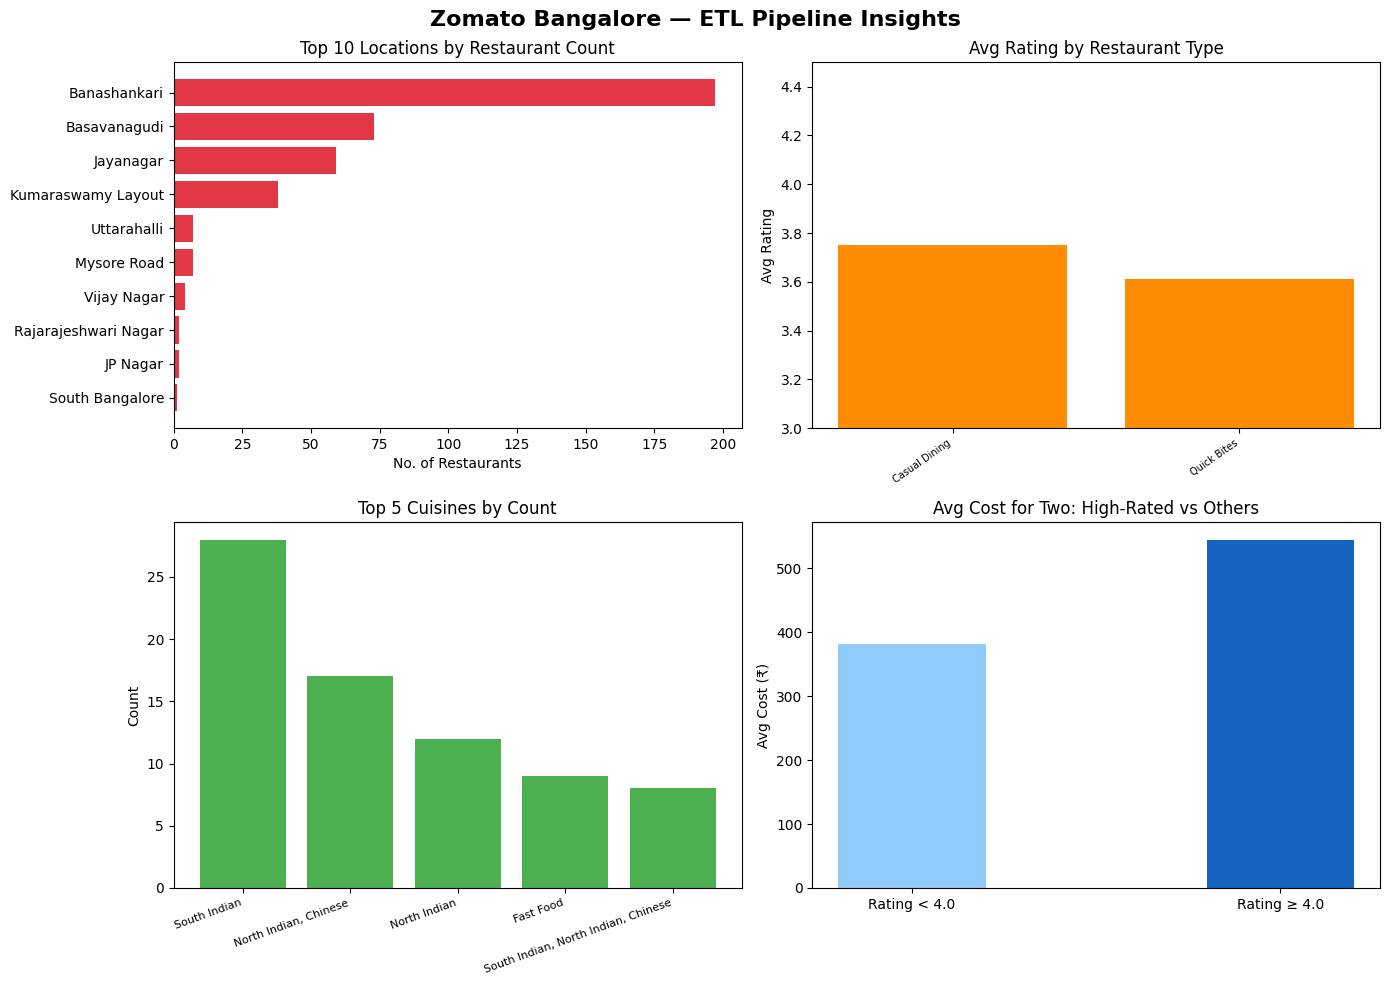

✅ Charts saved!


In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Zomato Bangalore — ETL Pipeline Insights",
             fontsize=16, fontweight="bold")

# Chart 1 — Top 10 Locations
ax = axes[0, 0]
ax.barh(q1["location"][::-1], q1["total_restaurants"][::-1], color="#E23744")
ax.set_title("Top 10 Locations by Restaurant Count")
ax.set_xlabel("No. of Restaurants")

# Chart 2 — Avg Rating by Type
ax = axes[0, 1]
ax.bar(q2["restaurant_type"], q2["avg_rating"], color="#FF8C00")
ax.set_title("Avg Rating by Restaurant Type")
ax.set_ylabel("Avg Rating")
ax.set_xticklabels(q2["restaurant_type"], rotation=35, ha="right", fontsize=7)
ax.set_ylim(3.0, 4.5)

# Chart 3 — Top 5 Cuisines
ax = axes[1, 0]
ax.bar(q4["cuisines"], q4["count"], color="#4CAF50")
ax.set_title("Top 5 Cuisines by Count")
ax.set_ylabel("Count")
ax.set_xticklabels(q4["cuisines"], rotation=20, ha="right", fontsize=8)

# Chart 4 — High Rated vs Cost
q5 = pd.read_sql_query("""
    SELECT is_high_rated, ROUND(AVG(cost_for_two), 0) AS avg_cost
    FROM restaurants
    WHERE cost_for_two IS NOT NULL AND is_high_rated IS NOT NULL
    GROUP BY is_high_rated
""", conn)
ax = axes[1, 1]
ax.bar(["Rating < 4.0", "Rating ≥ 4.0"], q5["avg_cost"],
       color=["#90CAF9", "#1565C0"], width=0.4)
ax.set_title("Avg Cost for Two: High-Rated vs Others")
ax.set_ylabel("Avg Cost (₹)")

plt.tight_layout()
plt.savefig("zomato_insights.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Charts saved!")

conn.close()